---
## Section 3 — MCP Neurons
### Task 1: Implementation of MCP Neurons

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### AND Gate — MCP Neuron

**Threshold selection reasoning:**  
AND is true only when **both** inputs are 1 → sum must equal 2.  
Setting T = 2 means: fire iff x1 + x2 ≥ 2, i.e., both are 1. ✓

In [2]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND gate using a McCulloch-Pitts neuron.

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have equal length."

    # Step 1 — element-wise sum of the two input arrays
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 — apply threshold: output 1 if sum >= T, else 0
    state_neuron = [1 if s >= T else 0 for s in sums]

    return state_neuron


# --- Sample usage ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # AND threshold: both inputs must fire

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate | inputs X1={X1}, X2={X2} | T={T}")
print(f"Output  : {result_and}")
print(f"Expected: [0, 0, 0, 1]")

AND gate | inputs X1=[0, 0, 1, 1], X2=[0, 1, 0, 1] | T=2
Output  : [0, 0, 0, 1]
Expected: [0, 0, 0, 1]


#### OR Gate — MCP Neuron

**Threshold selection reasoning:**  
OR is true when **at least one** input is 1 → sum ≥ 1.  
Setting T = 1 correctly captures this. ✓

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR gate using a McCulloch-Pitts neuron.

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have equal length."

    # Step 1 — element-wise sum
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 — apply threshold
    state_neuron = [1 if s >= T else 0 for s in sums]

    return state_neuron


# --- Sample usage ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # OR threshold: at least one input must fire

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR gate  | inputs X1={X1}, X2={X2} | T={T}")
print(f"Output  : {result_or}")
print(f"Expected: [0, 1, 1, 1]")

OR gate  | inputs X1=[0, 0, 1, 1], X2=[0, 1, 0, 1] | T=1
Output  : [0, 1, 1, 1]
Expected: [0, 1, 1, 1]


---
### Task 1 — Written Questions

#### Question 1: Limitations of MCP Neurons

1. **Fixed, hand-crafted weights** — All inputs contribute equally (weight = 1). There is no mechanism to learn which inputs matter more; the designer must hard-code every threshold manually.

2. **Binary inputs only** — Inputs must be 0 or 1. Real-world signals are continuous; MCP cannot process them without external discretisation.

3. **Binary output only** — The neuron outputs only 0 or 1. No probabilistic or graded response is possible.

4. **No learning algorithm** — MCP has no update rule. It cannot improve from data; the threshold T and the topology must be designed by hand for every new problem.

5. **Cannot represent XOR (non-linearly separable functions)** — A single MCP neuron computes a linear threshold function. XOR is not linearly separable, so no single threshold T exists that correctly classifies all four XOR input pairs.

6. **No bias term** — The decision boundary always passes through the origin (no offset), severely restricting which functions can be represented.

7. **Inhibitory inputs are absolute** — A single inhibitory input overrides the entire computation regardless of other inputs. This is an overly rigid model of biological inhibition.

8. **Biologically inaccurate** — Ignores timing, spike rates, neuro-chemical variation, and other known biological mechanisms; the model is too simplified to make neuroscientific conclusions.

---

#### Question 2: Can XOR be solved with a single MCP Neuron? Devise if-else rules.

**Short answer: No.** A single MCP neuron cannot solve XOR.

**Why not?**  
XOR truth table:

| X1 | X2 | XOR |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

The MCP neuron computes g(X) = X1 + X2 and fires if g(X) ≥ T.  
- For g(X) = 0 → output 0 ✓  
- For g(X) = 1 → output 1 ✓  
- For g(X) = 2 → output must be **0**, but with any fixed T ≤ 1, g(X)=2 ≥ T → output 1 ✗  

No single threshold T separates {0,1} from {2} on the number line in the required way.

**Workaround using TWO MCP neurons (if-else logic):**

```
XOR(X1, X2):
    OR_result  = MCP_OR(X1, X2,  T=1)   # fires if at least one is 1
    AND_result = MCP_AND(X1, X2, T=2)   # fires only if both are 1
    if OR_result == 1 AND AND_result == 0:
        return 1
    else:
        return 0
```

This is effectively: XOR = OR AND (NOT AND), which requires a 2-layer network — demonstrating that non-linearly separable problems demand multiple neurons.

In [4]:
# Demonstration: XOR using two MCP neurons
def MCP_Neurons_XOR(X1, X2):
    """
    XOR using two MCP neurons:
      - Neuron 1: OR  (T=1)
      - Neuron 2: AND (T=2)
      - Output  : OR AND (NOT AND)
    """
    or_out  = MCP_Neurons_OR(X1,  X2, T=1)
    and_out = MCP_Neurons_AND(X1, X2, T=2)
    state_neuron = [1 if (o == 1 and a == 0) else 0
                    for o, a in zip(or_out, and_out)]
    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
print(f"XOR result : {MCP_Neurons_XOR(X1, X2)}")
print(f"Expected   : [0, 1, 1, 0]")

XOR result : [0, 1, 1, 0]
Expected   : [0, 1, 1, 0]


---
## Section 4 — The Perceptron
### Task 2: Perceptron for 0 vs 1 Classification (MNIST)

#### Step 2 — Load the Dataset

In [6]:
# Load dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values   # shape: (n_samples, 784)
y = df_0_1["label"].values                  # shape: (n_samples,)

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)

Feature matrix shape: (4638, 784)
Label vector shape  : (4638,)


#### Written Answers — Dataset Shape

**Question 1: What does the shape of X represent?**  
X.shape = (n_samples, 784).  
- **n_samples** = number of images in the dataset.  
- **784** = 28 × 28 pixels, each image flattened into a 1-D feature vector. Each column is one pixel intensity (0–255).

**Question 2 (duplicate — likely meant "shape of y"):** What does the shape of y represent?  
y.shape = (n_samples,).  
It is a 1-D array containing the class label (0 or 1) for each corresponding image in X.

#### Visualize the Dataset

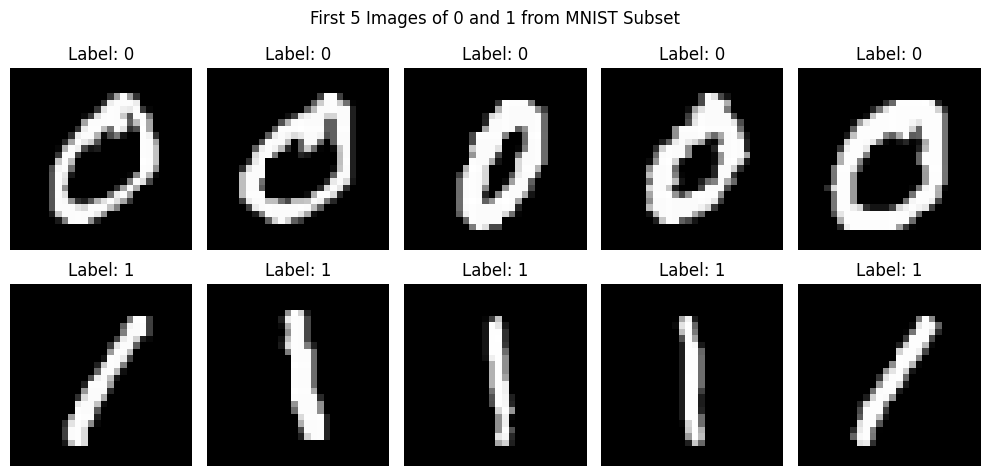

In [7]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

#### Step 3 — Initialize Weights and Bias

In [8]:
weights       = np.zeros(X.shape[1])   # 784 weights, one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

#### Written Answers — Initialization

**Question 3: What does the weights array represent in this context?**  
Each element `weights[j]` is the learnable importance assigned to pixel j (feature j).  
During training, pixels that are consistently dark for one class and bright for the other will receive large positive or negative weights. Pixels that are uninformative will converge toward zero.

**Question 4: Why initialize weights to zero? What effect could this have?**  
- **Why zero:** It is a convenient, neutral starting point. For the perceptron (single-neuron, no hidden layers) this does not cause a symmetry-breaking problem, because each input pixel has its own independent weight — there is no redundancy to break.
- **Potential effect:** All weights start identical, so the first prediction is always the same (ŷ = 0 for all inputs when z = 0 and the step function returns 0). The perceptron will then receive weight updates only from the positive class (y=1) misclassifications first, which is fine — it will still converge.
- **Contrast with deep networks:** Zero initialization is problematic in multi-layer networks because all neurons in a layer compute the same gradient (symmetry problem), preventing them from learning different features. For a single perceptron this is not an issue.

#### Step 4 — Decision Function (Activation / Step Function)

In [9]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels for input data using the step activation function.

    Parameters:
        X       : ndarray of shape (n_samples, n_features)
        weights : ndarray of shape (n_features,)
        bias    : scalar

    Returns:
        y_pred_all : ndarray of shape (n_samples,) with values in {0, 1}
    """
    # Compute the net weighted input for every sample at once (vectorised)
    # predictions[i] = dot(X[i], weights) + bias
    predictions = np.dot(X, weights) + bias

    # Step (Heaviside) activation: 1 if z >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

#### Step 5 — Perceptron Learning Algorithm

In [10]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : ndarray (n_samples, n_features) — input features
        y             : ndarray (n_samples,)            — true labels {0, 1}
        weights       : ndarray (n_features,)           — initial weights
        bias          : scalar                          — initial bias
        learning_rate : float                           — η (step size)
        epochs        : int                             — max training iterations

    Returns:
        weights  : updated weight vector
        bias     : updated bias
        accuracy : fraction of correctly classified training samples (final epoch)
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True          # assume converged until a misclassification is found
        correct          = 0

        for i in range(n_samples):
            # --- Forward pass ---
            # Compute weighted sum for sample i
            # z = w · x_i + b
            z = np.dot(X[i], weights) + bias

            # Apply step activation function
            y_hat = 1 if z >= 0 else 0

            # --- Weight update (only on misclassification) ---
            if y_hat != y[i]:
                error = y[i] - y_hat            # +1 or -1

                # Update each weight: w_j ← w_j + η * error * x_j
                weights = weights + learning_rate * error * X[i]

                # Update bias: b ← b + η * error  (bias input x_0 = 1 always)
                bias    = bias    + learning_rate * error

                convergence_flag = False         # at least one update happened
            else:
                correct += 1

        # --- Early stopping if perfectly classified ---
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}.")
            accuracy = 1.0
            return weights, bias, accuracy

    # Compute final accuracy after all epochs
    y_pred_final = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy     = np.mean(y_pred_final == y)

    return weights, bias, accuracy

#### Written Answers — Algorithm Questions

**Question 5: What does `output = np.dot(X[i], weights) + bias` do?**  
It computes the **net weighted input** (also called the pre-activation or logit) for sample i:  
> z = w₁x₁ + w₂x₂ + … + w₇₈₄x₇₈₄ + b  

This is a dot product — each pixel intensity is multiplied by its corresponding learned weight, then summed, and the bias is added. The resulting scalar z is then passed to the step function to produce the prediction.

**Question 6: What happens when the prediction is wrong? How are weights and bias updated?**  
When ŷ ≠ y (misclassification), the error signal `error = y - ŷ` is either +1 or -1:  
- If y=1 and ŷ=0 (false negative): error = +1 → weights are **increased** in the direction of X[i] → pushes z upward → makes firing more likely for similar inputs next time.  
- If y=0 and ŷ=1 (false positive): error = -1 → weights are **decreased** → suppresses firing for similar inputs.  

Update rules:  
> wⱼ ← wⱼ + η · (y − ŷ) · xⱼ  
> b  ← b  + η · (y − ŷ)  

The bias is treated as a weight with a constant input of 1, so it shifts the decision boundary without depending on any feature.

**Question 7: Why is final accuracy important, and what do you expect it to be?**  
Final accuracy tells us whether the perceptron has found a valid separating hyperplane for the training data.  
- 0 and 1 are visually very distinct — their pixel distributions overlap minimally.  
- The data is nearly linearly separable in pixel space.  
- **Expected accuracy: ~99–100%** for this binary pair after sufficient epochs.  

Accuracy is the primary evaluation metric here because the two classes are roughly balanced in the MNIST subset.

#### Step 6 — Train the Perceptron

In [11]:
# Re-initialise to ensure a clean run
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=learning_rate,
                                           epochs=epochs)
print(f"Final Training Accuracy (0 vs 1): {accuracy:.4f}")

Converged at epoch 8.
Final Training Accuracy (0 vs 1): 1.0000


#### Step 7 — Visualize Misclassified Images

In [12]:
# Final predictions
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Identify misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    rows   = (n_show + 4) // 5   # up to 2 rows of 5
    fig, axes = plt.subplots(rows, 5, figsize=(10, rows * 2.5))
    axes = axes.flat

    for ax, idx in zip(axes, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]}, True:{y[idx]}", fontsize=8)
        ax.axis("off")

    # Hide unused subplot slots
    for ax in list(axes)[n_show:]:
        ax.set_visible(False)

    plt.suptitle(f"Misclassified Images — 0 vs 1 ({len(misclassified_idx)} total)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


#### Written Answers — Visualization Questions

**Question 8: What does `misclassified_idx` store, and how is it used?**  
`misclassified_idx` stores the **integer indices** of all samples where `y_pred[i] ≠ y[i]`.  
It is produced by `np.where(y_pred != y)[0]`, which returns a 1-D array of positions.  
It is then used to:  
1. Check whether any misclassifications exist (`len(misclassified_idx) > 0`).  
2. Retrieve the actual pixel data `X[idx]` and both predicted/true labels for each misclassified sample, so they can be rendered in a grid with `imshow`.

**Question 9: How do you interpret "All images were correctly classified!"?**  
It means the perceptron found a **linear decision boundary** in the 784-dimensional pixel space that perfectly separates all 0s from all 1s in the training set — the perceptron converged.  

**Important caveat:** This does **not** guarantee generalisation. It only confirms the training data is linearly separable with respect to the learned weights. On unseen test data there may still be errors. To evaluate real performance, a held-out test set should be used.

---
## Section 4.4 — Task 3: Perceptron for 3 vs 5 Classification

In [14]:
# ── Step 1: Load dataset ────────────────────────────────────────────────────
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")

X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

# Convert labels to binary: 3 → 0, 5 → 1
# This is required because the perceptron step function outputs {0,1}
y_35_binary = np.where(y_35 == 5, 1, 0)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape  :", y_35_binary.shape)
print("Unique original labels:", np.unique(y_35))

Feature matrix shape: (2741, 784)
Label vector shape  : (2741,)
Unique original labels: [3 5]


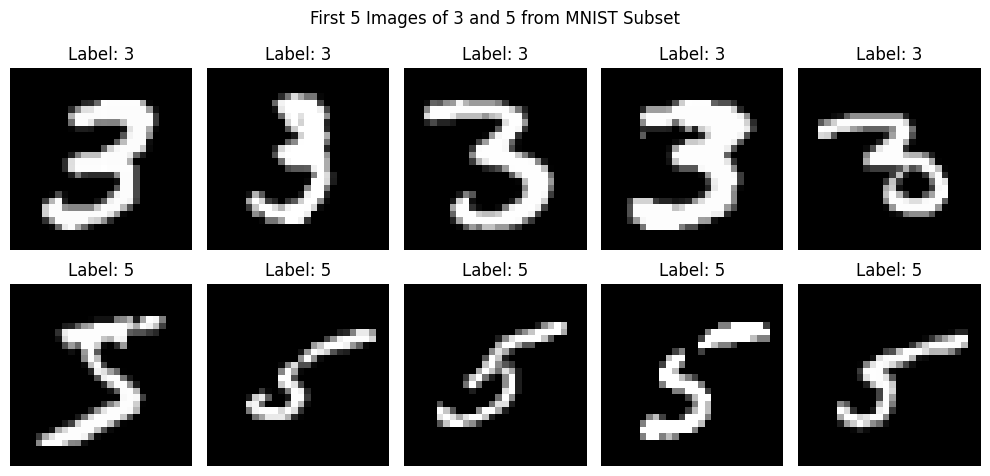

In [15]:
# ── Step 2: Visualize ───────────────────────────────────────────────────────
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [16]:
# ── Step 3: Initialize weights ──────────────────────────────────────────────
weights_35       = np.zeros(X_35.shape[1])
bias_35          = 0
learning_rate_35 = 0.1
epochs_35        = 100

In [17]:
# ── Step 4 & 5: Train perceptron ────────────────────────────────────────────
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary,
    weights_35, bias_35,
    learning_rate=learning_rate_35,
    epochs=epochs_35
)
print(f"Final Training Accuracy (3 vs 5): {accuracy_35:.4f}")

Final Training Accuracy (3 vs 5): 0.9869


Final Accuracy (3 vs 5): 0.9869


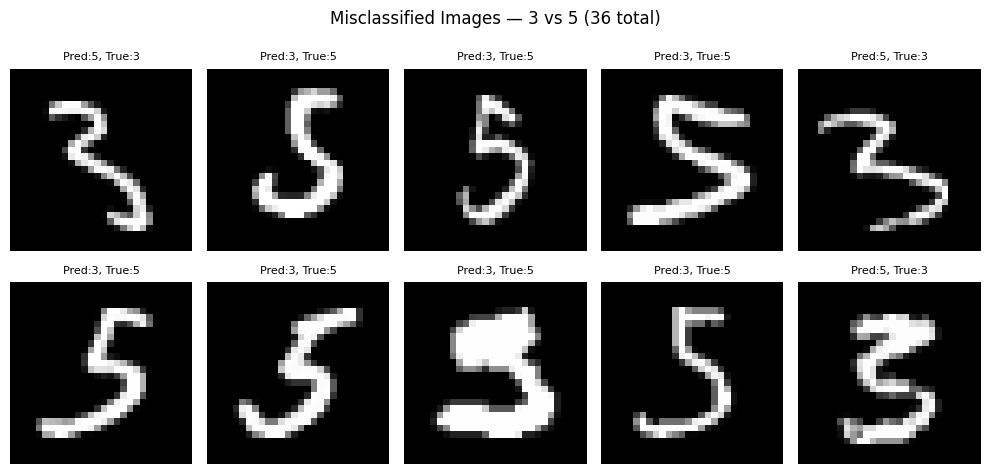

In [18]:
# ── Step 6: Visualize misclassified images ──────────────────────────────────
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35      = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")

# Recover original labels for readable plot titles
y_pred_label = np.where(y_pred_35 == 1, 5, 3)
y_true_label = y_35   # original labels

misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

if len(misclassified_idx_35) > 0:
    n_show = min(10, len(misclassified_idx_35))
    rows   = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(10, rows * 2.5))
    axes = axes.flat

    for ax, idx in zip(axes, misclassified_idx_35[:n_show]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred_label[idx]}, True:{y_true_label[idx]}", fontsize=8)
        ax.axis("off")

    for ax in list(axes)[n_show:]:
        ax.set_visible(False)

    plt.suptitle(f"Misclassified Images — 3 vs 5 ({len(misclassified_idx_35)} total)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

### Conclusion — Task 3: 3 vs 5 Classification

**Why 3 vs 5 is harder than 0 vs 1:**  
The digits 3 and 5 share significant structural overlap — both have curved upper-left portions and open rightward — making them far less linearly separable in raw pixel space than 0 and 1.

**Expected outcome:**  
- Accuracy will be lower than the 0 vs 1 case, likely in the **85–95%** range depending on the dataset size and variability.  
- The perceptron may **fail to converge** within 100 epochs if the classes are not perfectly linearly separable, iterating until the epoch limit.

**Evidence from misclassified images (Figure 6 in the worksheet):**  
The shown misclassifications are visually ambiguous handwritten digits where the strokes of 3 and 5 are genuinely similar — confirming that the remaining errors are structurally difficult boundary cases, not random noise.

**Core limitation exposed:**  
This task demonstrates the fundamental perceptron limitation: it can only learn a **linear decision boundary**. When the boundary between classes is curved or complex, a single perceptron is provably insufficient. Multi-layer networks (MLPs) with non-linear activations are required for such cases.